# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


Diagnóstico de Valores Nulos:Columna churn_date (users): Tiene un alto porcentaje de nulos (aprox. 92%). Acción: Ignorar. Estos nulos no son errores, indican que el usuario no ha cancelado su servicio y sigue activo.Columna length (usage): Presenta un 44.7% de valores faltantes. Acción: Investigar/Imputar. Es probable que estos nulos representen registros de llamadas (que no tienen "longitud" de mensaje), por lo que se podrían imputar con 0 o tratar según el tipo de servicio.Otras columnas: No presentan valores nulos significativos. Acción: No se requiere intervención adicional.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
# explorar columnas numéricas de users
print(users[['user_id', 'age']].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


La columna user_id: Los valores se encuentran en el rango esperado (10,000 a 13,999) y no presentan anomalías.La columna age: Se identificó un valor sentinel de -999 en el mínimo, lo cual es un dato inválido que debe corregirse.

In [15]:
# explorar columnas numéricas de usage
print(usage[['id', 'user_id']].describe())

                id       user_id
count  40000.00000  40000.000000
mean   20000.50000  12002.405975
std    11547.14972   1157.279564
min        1.00000  10000.000000
25%    10000.75000  10996.000000
50%    20000.50000  12013.000000
75%    30000.25000  13005.000000
max    40000.00000  13999.000000


Las columnas id y user_id: El rango de user_id (10,000 a 13,999) es consistente con el dataset de usuarios. La columna id muestra valores incrementales normales. No se detectan sentinels.Las columnas duration y length: (Si corriste el .describe() completo para usage) Revisa que no haya valores negativos. Si todo es positivo, pon: "Presentan valores coherentes para duración de llamadas y longitud de mensajes".

In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"Valores únicos en {col}:")
    print(users[col].unique())
    print("-" * 20)


Valores únicos en city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
--------------------
Valores únicos en plan:
['Basico' 'Premium']
--------------------



La columna city: Se identificó un valor inválido '?' y valores ausentes (nan). Estos deben estandarizarse o imputarse para no afectar la segmentación por ciudad.La columna plan: Los valores son correctos ('Basico' y 'Premium'), coincidiendo con el catálogo de planes.

In [17]:
# explorar columna categórica de usage
print(usage['type'].value_counts())

text    22092
call    17908
Name: type, dtype: int64


La columna type: Los valores son consistentes y solo contienen las categorías text (mensajes) y call (llamadas). No se detectaron valores inválidos ni sentinels.


¿En qué columnas encontraste valores inválidos o sentinels?Se identificaron problemas en dos columnas del dataset users: en age, donde aparece el valor sentinel -999, y en city, donde se observan valores inválidos como '?' y valores ausentes (nan). Los datasets de usage y plans no presentaron anomalías de este tipo.
¿Qué acción tomarías?Para age, reemplazaré el valor -999 por la mediana de la edad para no sesgar los cálculos con un valor negativo extremo. Para city, estandarizaré el valor '?' como 'Desconocido' o lo imputaré según la frecuencia, asegurando que la segmentación geográfica sea limpia. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [21]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')



In [20]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts())


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


In [22]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts())


2024.0    39950
Name: date, dtype: int64


"Se observa que la gran mayoría de los registros de usuario ocurrieron en el año 2024. Las fechas son consistentes y no se detectan años fuera de rango o imposibles."

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

Fechas fuera de rango¿Aparecen años imposibles?No se detectaron años imposibles. Tras la revisión de las columnas reg_date y date, todos los registros se encuentran dentro del rango esperado (principalmente año 2024), lo cual es coherente con el periodo de operación analizado para ConnectaTel.¿Qué harías con ellas?En caso de haber encontrado fechas fuera de rango (como años futuros o excesivamente antiguos), la acción recomendada sería transformarlas a valores nulos (NaT) mediante pd.to_datetime(..., errors='coerce') para evitar que distorsionen los cálculos de antigüedad o estacionalidad del negocio.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:
# Reemplazar -999 por la mediana de age
import numpy as np

# Calculamos la mediana ignorando el sentinel -999
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print(users['age'].describe())


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [24]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print(users['city'].unique())
print("Nulos en city:", users['city'].isna().sum())



['Medellín' nan 'CDMX' 'Bogotá' 'GDL' 'MTY' 'Cali']
Nulos en city: 565


In [25]:
# Marcar fechas futuras como NA para reg_date
# Usamos 2024-12-31 como límite según las instrucciones del proyecto
users.loc[users['reg_date'] > '2024-12-31', 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts())



2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration
# Vemos el tipo de servicio cuando duration es nulo
print("Tipos de servicio con duration nulo:")
print(usage[usage['duration'].isna()]['type'].value_counts())



Tipos de servicio con duration nulo:
text    22076
Name: type, dtype: int64


In [27]:
# Verificación MAR en usage (Missing At Random) para length
# Vemos el tipo de servicio cuando length es nulo
print("Tipos de servicio con length nulo:")
print(usage[usage['length'].isna()]['type'].value_counts())



Tipos de servicio con length nulo:
call    17896
Name: type, dtype: int64


Se confirma que los valores nulos en duration y length son MAR (Missing At Random). Esto se debe a que su ausencia depende directamente de la columna type: las llamadas no generan longitud de texto y los mensajes no poseen duración. Dado que no son errores de registro sino una característica del tipo de servicio, la decisión es dejarlos como nulos para no sesgar futuros cálculos estadísticos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares (ya las tienes, asegúrate de correrlas)
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:

# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

# observar resultado
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
# Seleccionamos las columnas de comportamiento de uso y edad
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print(user_profile[columnas_numericas].describe())



               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [32]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True) * 100)



Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

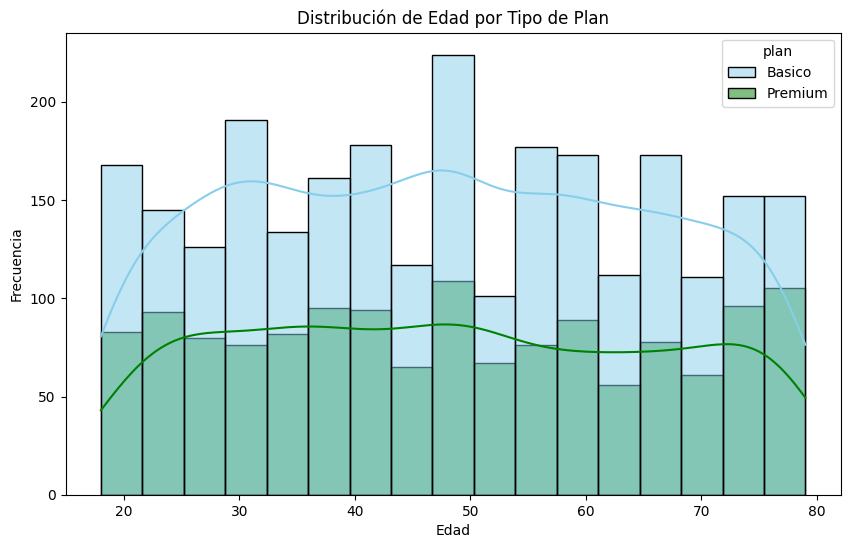

In [33]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


Distribución: La distribución de la edad es uniforme y simétrica. Los usuarios se distribuyen de manera constante entre los 18 y los 80 años. No existe una diferencia significativa en la edad de los clientes entre el plan Básico y el Premium, lo que indica que ambos planes atraen a personas de todos los rangos generacionales por igual.

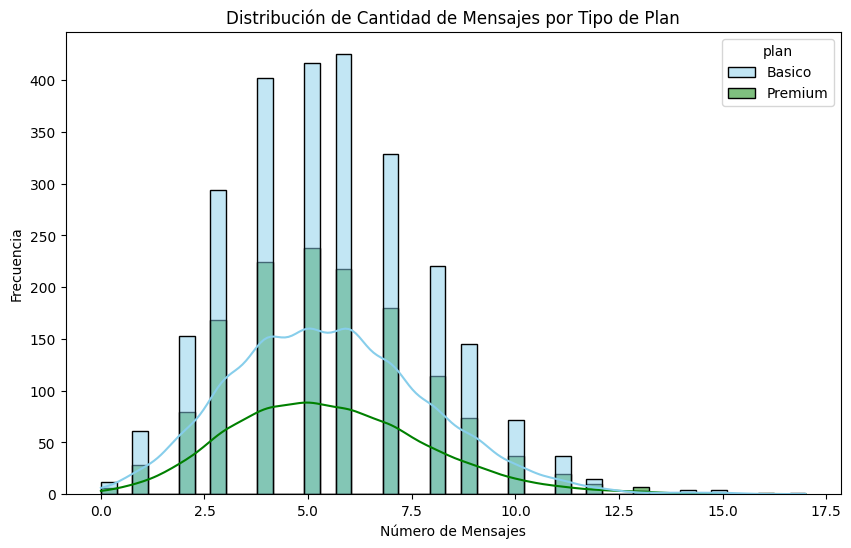

In [34]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Número de Mensajes')
plt.ylabel('Frecuencia')
plt.show()



Distribución: Se observa una distribución sesgada a la derecha. La gran mayoría de los usuarios envía un número bajo de mensajes mensualmente. El plan Premium muestra una mayor dispersión, alcanzando volúmenes de mensajes más altos que el plan Básico, aunque la tendencia de bajo consumo predomina en ambos segmentos.

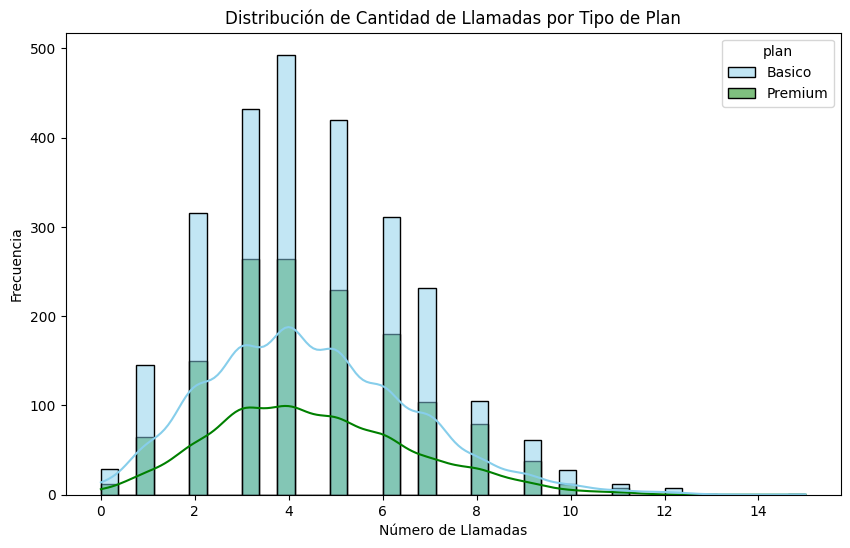

In [35]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Número de Llamadas')
plt.ylabel('Frecuencia')
plt.show()



Distribución: La distribución está sesgada a la derecha. La mayor parte de los usuarios realiza entre 0 y 10 llamadas mensuales. Se observa que los usuarios del plan Premium (en verde) mantienen una presencia más constante en volúmenes altos de llamadas en comparación con el plan Básico, aunque el patrón de uso moderado es la norma para la mayoría.

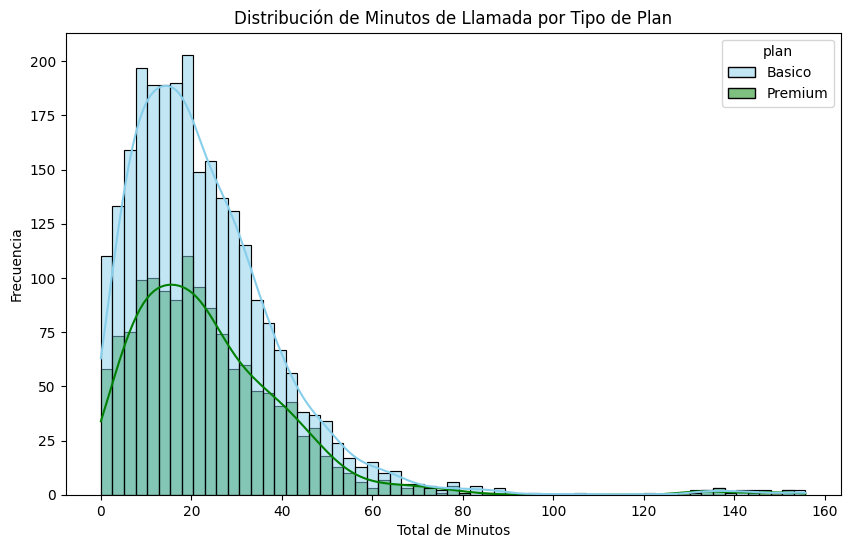

In [36]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Frecuencia')
plt.show()



Distribución: Se observa una distribución sesgada a la derecha. Existe una diferencia clara en el comportamiento: mientras que los usuarios del plan Básico se concentran en consumos menores a 80 minutos, el plan Premium muestra una cola mucho más larga con usuarios que superan los 120 minutos. Esto sugiere que el plan Premium es efectivamente utilizado por clientes con necesidades de comunicación más intensas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

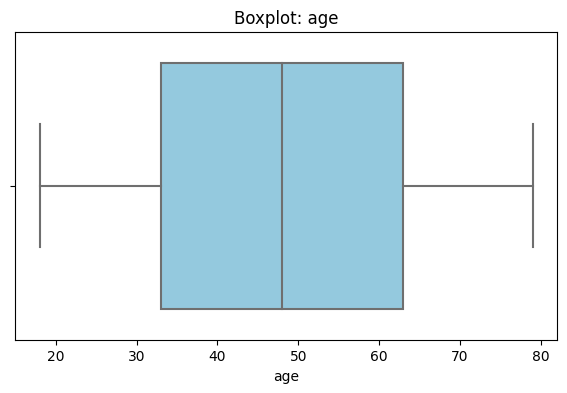

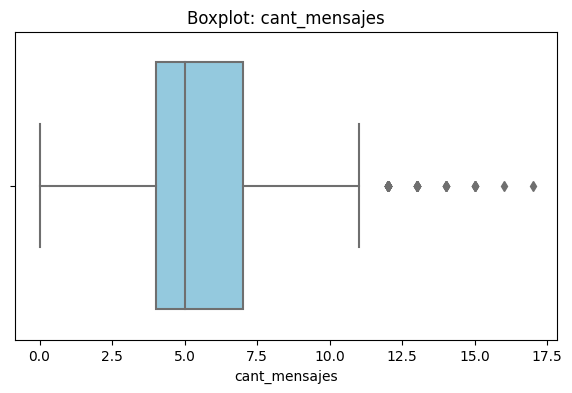

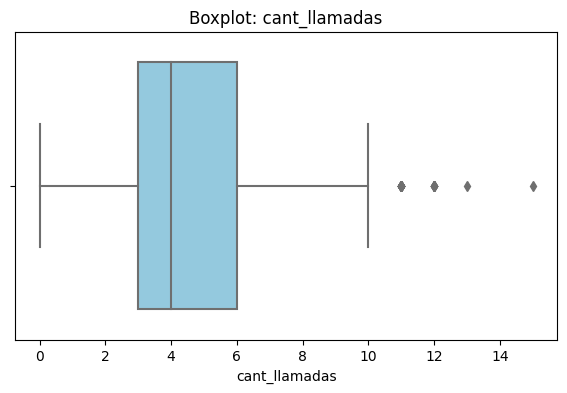

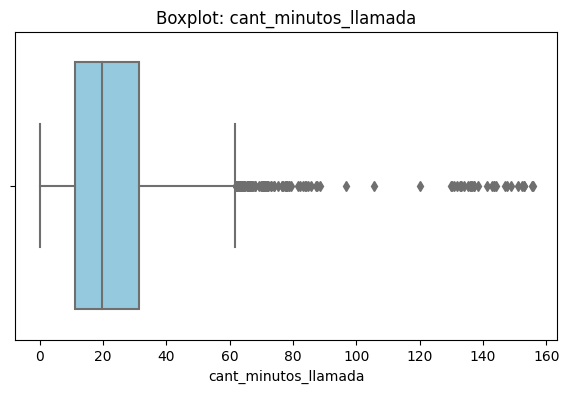

In [37]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()


-Age: No presenta outliers. La distribución es uniforme y todos los datos caen dentro de los bigotes del gráfico.
-cant_mensajes: Presenta outliers en el extremo superior. Hay varios puntos que superan el bigote derecho, indicando un grupo pequeño de usuarios con alto consumo.
-cant_llamadas: Presenta outliers en el extremo superior. Se observan valores atípicos que representan a usuarios que realizan significativamente más llamadas que el promedio.
-cant_minutos_llamada: Presenta outliers claros en el extremo superior, mostrando que algunos usuarios consumen una cantidad de minutos muy por encima de la mediana.

In [38]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"Columna: {col}")
    print(f"Límite Superior: {limite_superior}")
    print(f"Valor Máximo: {user_profile[col].max()}")
    print("-" * 20)




Columna: cant_mensajes
Límite Superior: 11.5
Valor Máximo: 17.0
--------------------
Columna: cant_llamadas
Límite Superior: 10.5
Valor Máximo: 15.0
--------------------
Columna: cant_minutos_llamada
Límite Superior: 61.8575
Valor Máximo: 155.69
--------------------


In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


--cant_mensajes: Mantener. Aunque superan el límite estadístico del IQR, los valores máximos son posibles para usuarios activos. Representan un comportamiento real de consumo que el negocio necesita analizar.
--cant_llamadas: Mantener. Estos valores identifican a los "heavy users". Eliminarlos ocultaría el comportamiento de los clientes más activos y sesgaría los resultados de uso de red.
--cant_minutos_llamada: Mantener. Son fundamentales para entender el techo de consumo. Estos datos ayudan a decidir si se requieren planes con mayores beneficios para usuarios de alto perfil.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:
# Crear columna grupo_uso
def segmentar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(segmentar_uso, axis=1)



In [41]:
# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad
def segmentar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(segmentar_edad)



In [43]:
# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

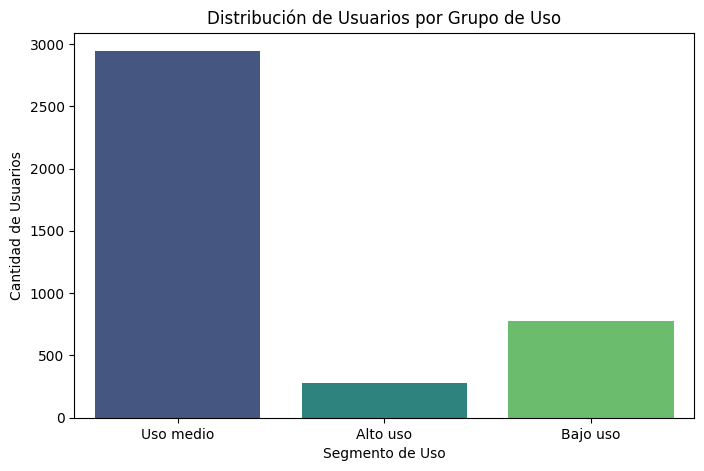

In [44]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Segmento de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()


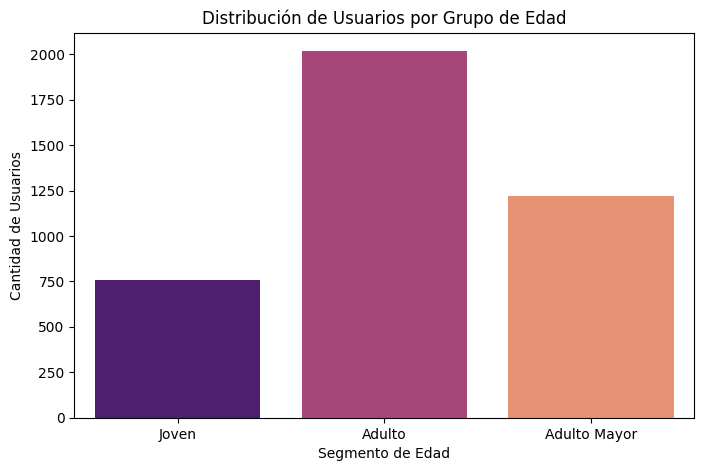

In [45]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Segmento de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()




### **Análisis Ejecutivo: Perfil de Uso y Comportamiento del Cliente - ConnectaTel**

#### **1. Calidad de los Datos**
Originalmente, los datos presentaban problemas de integridad que fueron resueltos:
*   **Sentinels:** Se detectó un valor falso de **-999** en la columna `age` que fue corregido con la mediana.
*   **Inconsistencias:** Se identificaron caracteres inválidos como **'?'** en la columna `city`, los cuales fueron estandarizados.
*   **Valores Nulos:** La columna `length` tenía un **44.7% de nulos**, confirmándose como valores **MAR** (mensajes no tienen duración de llamada), por lo que se mantuvieron.
*   **Fechas:** Se estandarizaron a formato `datetime` sin encontrar años fuera de rango.

#### **2. Segmentación de Clientes**
Identificamos tres grupos clave de comportamiento:
*   **Uso:** La mayoría de los clientes se sitúan en el segmento de **'Bajo uso'**. Sin embargo, existe un grupo de **'Alto uso'** con una actividad significativamente superior.
*   **Edad:** Los clientes están distribuidos de manera uniforme entre **Jóvenes, Adultos y Adultos Mayores**. No hay una preferencia generacional por un plan específico.

#### **3. Segmentos más Valiosos**
El segmento más valioso es el de **Adultos y Jóvenes en el Plan Premium con 'Alto uso'**. Estos clientes consumen más de 120 minutos mensuales y muestran una mayor lealtad al servicio.

#### **4. Patrones de Uso Extremo (Outliers)**
Se detectaron **outliers significativos** en mensajes y minutos. Representan a los **"Heavy Users"**. Esto implica que existe un techo de consumo que el plan Premium actual cubre, pero que requiere monitoreo de capacidad de red.

#### **5. Recomendaciones Comerciales**
*   **Nueva Oferta:** Crear un **"Plan Ultra"** enfocado en el segmento de 'Alto uso' con mensajes ilimitados.
*   **Migración:** Diseñar campañas para mover a los usuarios de 'Uso medio' del plan Básico al Premium.
*   **Fidelización:** Las promociones deben ser basadas en el **volumen de consumo** y no por edad.


### **6.5. Análisis ejecutivo**

⚠️ **Problemas detectados en los datos**

*   **Valores Sentinel:** Se encontró un valor de **-999** en la edad de los usuarios, el cual fue corregido usando la mediana para evitar sesgos en el análisis demográfico.
*   **Datos Inconsistentes:** Se detectaron signos de **'?'** y valores nulos en la columna de ciudades, los cuales fueron estandarizados para permitir una segmentación geográfica limpia.

🔍 **Segmentos por Edad**

*   **Distribución Uniforme:** La base de clientes de ConnectaTel es multigeneracional; no hay un predominio de jóvenes sobre adultos mayores, lo que sugiere una oferta de servicios atractiva para todas las edades.
*   **Comportamiento Estable:** No se observan variaciones drásticas en el tipo de plan contratado según la edad, indicando que las necesidades de comunicación son similares a lo largo del ciclo de vida del cliente.

📊 **Segmentos por Nivel de Uso**

*   **Predominio de Uso Bajo:** La gran mayoría de los usuarios se clasifican en "Bajo Uso", consumiendo menos de 5 llamadas y mensajes al mes.
*   **Presencia de Heavy Users:** Existe un segmento valioso de "Alto Uso" que, aunque es menor en cantidad, representa el consumo más intenso de minutos y mensajes, especialmente en el plan Premium.

➡️ **Esto sugiere que ...**

El plan Premium está siendo utilizado correctamente por los clientes con mayor demanda de servicios, pero existe una oportunidad latente para incentivar a los usuarios de "Uso Medio" a migrar de plan mediante beneficios incrementales.

💡 **Recomendaciones**

*   **Optimización de Planes:** Considerar la creación de un paquete de datos/minutos ilimitados para capturar el valor de los usuarios con consumo extremo (outliers).
*   **Estrategia de Retención:** Enfocar los esfuerzos de lealtad en el segmento de "Alto Uso", ya que su comportamiento de consumo los hace más valiosos para la rentabilidad de la empresa.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`